# Lecture 2 · Exercises

Code for [exercises.md](exercises.md)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("../../coding_tasks/Data/Out_Data")
GENDERS = ["female", "male"]
rng = np.random.default_rng(1234)

### Helpers

In [2]:
def strip_plot(df, y, jitter=0.0, ax=None):
    """Points per gender, optional horizontal jitter."""
    ax = ax or plt.gca()
    for i, g in enumerate(GENDERS):
        vals = df.loc[df["gender"] == g, y]
        x = i + rng.uniform(-jitter, jitter, len(vals))
        ax.scatter(x, vals, s=15)
    ax.set_xticks(range(len(GENDERS)), GENDERS)
    ax.set_xlim(-0.5, len(GENDERS) - 0.5)
    ax.set(xlabel="gender", ylabel=y)
    return ax


def box_plot(df, y, ax=None):
    """Box plot per gender."""
    ax = ax or plt.gca()
    ax.boxplot([df.loc[df["gender"] == g, y] for g in GENDERS])
    ax.set_xticks([1, 2], GENDERS)
    ax.set(xlabel="gender", ylabel=y)
    return ax

---

## Exercise 2.1 · Academic performance

### Data

In [3]:
df_math = pd.read_csv(DATA / "lecture2_math.csv")
print(df_math.shape)
df_math.head()

(86, 6)


,id,gender,math_points,gym_visits,countries,class_rating
0,1,male,130.1,10,4,very good
1,2,female,100.5,2,7,bad
2,3,female,90.9,0,1,medium
3,4,female,141.7,14,5,good
4,5,male,120.5,12,1,very bad


### 1–3 · Study designs

No code, see [exercises.md](exercises.md)

### 4 · Countries by gender

In [4]:
df_math.groupby("gender")["countries"].agg(["mean", "median", "std", "min", "max", "count"]).round(2)

,mean,median,std,min,max,count
gender,,,,,,
female,4.29,4.0,2.87,0,10,45
male,3.59,3.0,2.95,0,10,41


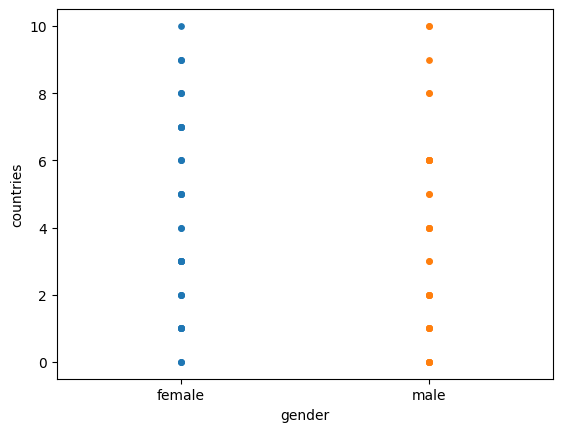

In [5]:
strip_plot(df_math, "countries")
plt.show()

### 5 · Overplotting

Students behind each dot

In [6]:
pd.crosstab(df_math["countries"], df_math["gender"])

gender,female,male
countries,,
0,3,7
1,7,6
2,4,6
3,8,2
4,2,5
5,5,2
6,3,8
7,6,0
8,3,2


Scatter vs. jitter vs. box plot

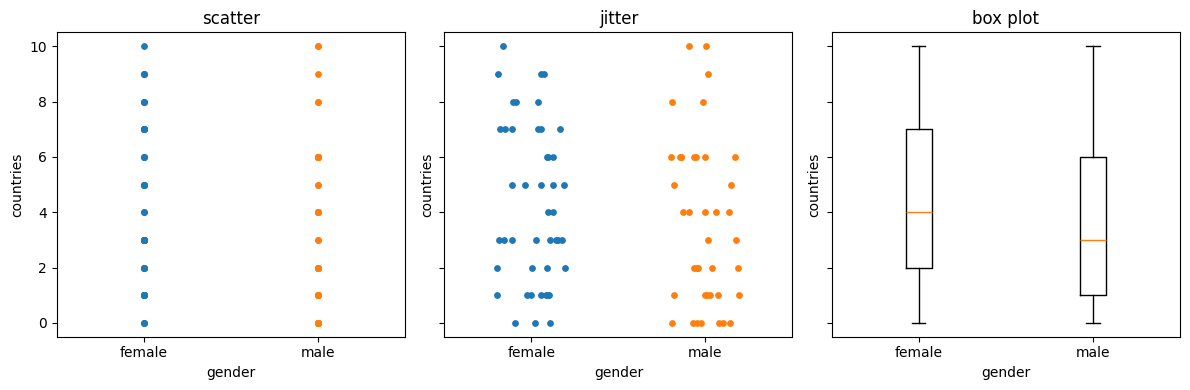

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
strip_plot(df_math, "countries", ax=axes[0]).set_title("scatter")
strip_plot(df_math, "countries", jitter=0.2, ax=axes[1]).set_title("jitter")
box_plot(df_math, "countries", ax=axes[2]).set_title("box plot")
plt.tight_layout()
plt.show()

### 6 · Gym visits by gender

In [8]:
df_math.groupby("gender")["gym_visits"].agg(["mean", "median", "std", "min", "max", "count"]).round(2)

,mean,median,std,min,max,count
gender,,,,,,
female,9.76,10.0,7.75,0,25,45
male,6.44,4.0,6.61,0,22,41


No gym visit

In [9]:
(
    df_math["gym_visits"].eq(0)
    .groupby(df_math["gender"])
    .agg(n_zero="sum", share_zero="mean")
    .round(2)
)

,n_zero,share_zero
gender,,
female,9,0.20
male,14,0.34


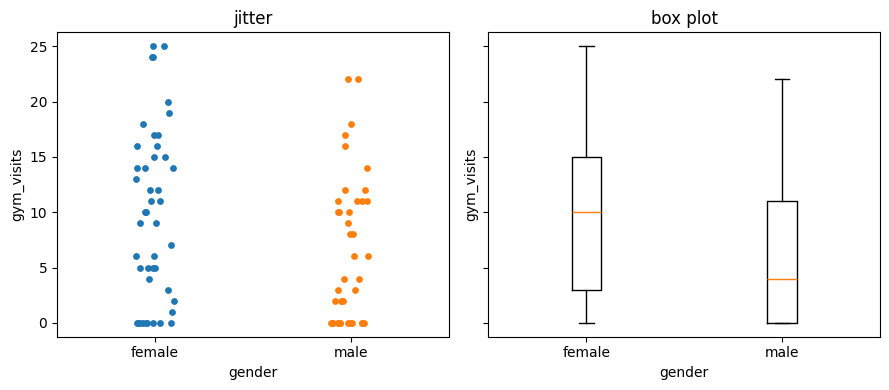

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
strip_plot(df_math, "gym_visits", jitter=0.1, ax=axes[0]).set_title("jitter")
box_plot(df_math, "gym_visits", ax=axes[1]).set_title("box plot")
plt.tight_layout()
plt.show()

### 7 · Countries vs. math points

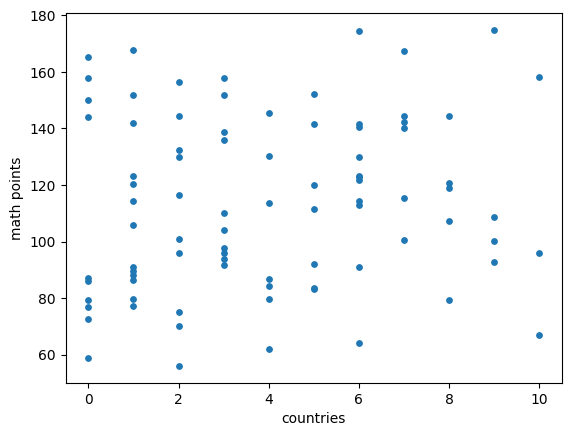

In [11]:
fig, ax = plt.subplots()
ax.scatter(df_math["countries"], df_math["math_points"], s=15)
ax.set(xlabel="countries", ylabel="math points")
plt.show()

Correlation (not part of lecture 2)

In [12]:
print(f"r = {df_math['countries'].corr(df_math['math_points']):.2f}")

r = 0.13


### 8 · Gym visits vs. math points

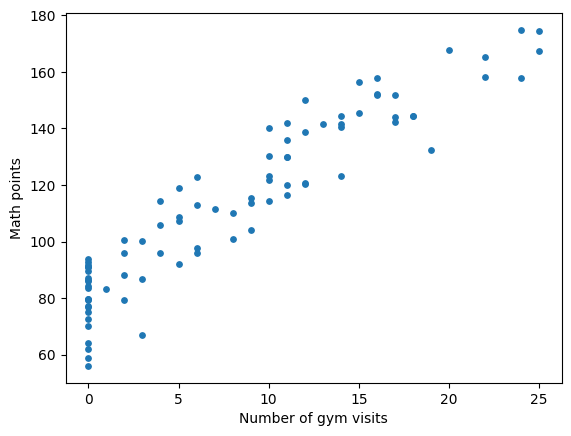

In [13]:
fig, ax = plt.subplots()
ax.scatter(df_math["gym_visits"], df_math["math_points"], s=15)
ax.set(xlabel="Number of gym visits", ylabel="Math points")
plt.show()

Correlation (not part of lecture 2)

In [14]:
print(f"r = {df_math['gym_visits'].corr(df_math['math_points']):.2f}")

r = 0.94


Math points: no visits vs. 20+ visits

In [15]:
visit_groups = pd.cut(df_math["gym_visits"], bins=[-1, 0, 19, 25], labels=["0", "1-19", "20+"])
df_math.groupby(visit_groups, observed=True)["math_points"].agg(["count", "min", "max", "mean"]).round(1)

,count,min,max,mean
gym_visits,,,,
0,23,56.0,93.7,79.5
1-19,56,67.1,157.7,121.0
20+,7,157.7,174.9,166.6


---

## Exercise 2.2 · GDP and life expectancy

### Data

In [16]:
df_gdp = pd.read_csv(DATA / "lecture2_gdp_life_expectancy.csv")
df_gdp.head()

,country,iso3c,region,capital,longitude,latitude,gdppc,life_expectancy
0,Afghanistan,AFG,South Asia,Kabul,69.17610,34.52280,0.413758,66.035
1,Albania,ALB,Europe & Central Asia,Tirane,19.81720,41.33170,8.575171,79.602
2,Algeria,DZA,Middle East & North Africa,Algiers,3.05097,36.73970,5.364028,76.261
3,Andorra,AND,Europe & Central Asia,Andorra la Vella,1.52180,42.50750,46.812448,84.041
4,Angola,AGO,Sub-Saharan Africa,Luanda,13.24200,-8.81155,2.309534,64.617


### 1 · Size

In [17]:
df_gdp.shape

(192, 8)

### 2 · Variable types

In [18]:
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          192 non-null    object 
 1   iso3c            192 non-null    object 
 2   region           192 non-null    object 
 3   capital          187 non-null    object 
 4   longitude        188 non-null    float64
 5   latitude         188 non-null    float64
 6   gdppc            192 non-null    float64
 7   life_expectancy  192 non-null    float64
dtypes: float64(4), object(4)
memory usage: 12.1+ KB


| Variable | Type | Scale |
| --- | --- | --- |
| `country`, `iso3c`, `region`, `capital` | regular categorical | nominal |
| `longitude`, `latitude` | continuous | interval |
| `gdppc`, `life_expectancy` | continuous | ratio |

Missing values

In [19]:
df_gdp.isna().sum()

country            0
iso3c              0
region             0
capital            5
longitude          4
latitude           4
gdppc              0
life_expectancy    0
dtype: int64

### 3 · Means per region

In [20]:
gdp_coll = (
    df_gdp.groupby("region")
    .agg(
        gdppc_mean=("gdppc", "mean"),
        gdppc_median=("gdppc", "median"),
        life_expectancy_mean=("life_expectancy", "mean"),
        no_countries=("country", "size"),
    )
    .sort_values("gdppc_mean")
)
gdp_coll.round(2)

,gdppc_mean,gdppc_median,life_expectancy_mean,no_countries
region,,,,
Sub-Saharan Africa,2.65,1.47,64.68,44
South Asia,3.55,2.54,72.78,8
Latin America & Caribbean,17.28,12.57,75.04,34
East Asia & Pacific,18.20,6.34,73.60,31
Middle East & North Africa,19.54,5.66,76.66,20
Europe & Central Asia,34.77,24.04,78.55,52
North America,89.71,82.30,80.78,3


North America: only 3 countries

In [21]:
df_gdp.loc[df_gdp["region"] == "North America", ["country", "gdppc", "life_expectancy"]]

,country,gdppc,life_expectancy
20,Bermuda,132.604439,82.309000
33,Canada,54.220329,81.646585
185,United States,82.304620,78.385366


### 4 · Regional graph

Countries vs. region means

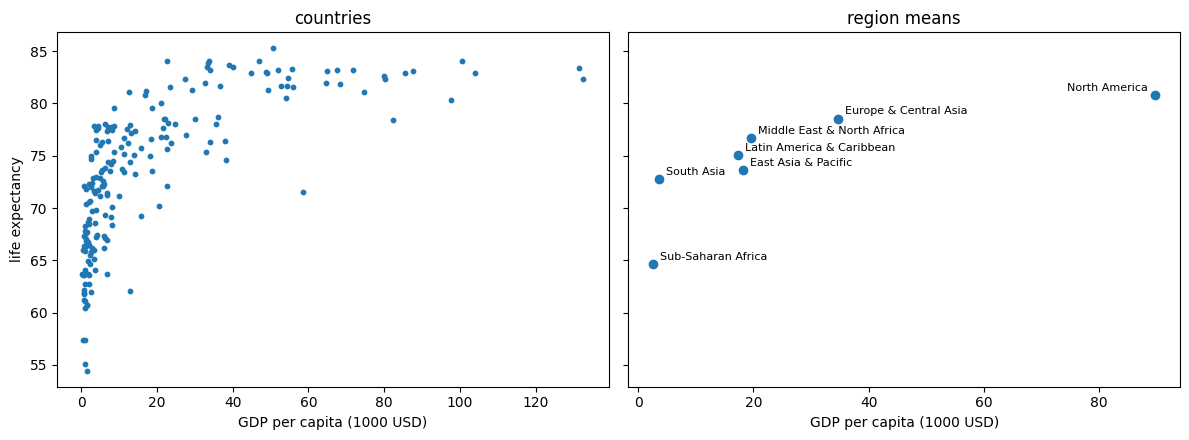

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].scatter(df_gdp["gdppc"], df_gdp["life_expectancy"], s=10)
axes[0].set(title="countries", xlabel="GDP per capita (1000 USD)", ylabel="life expectancy")

axes[1].scatter(gdp_coll["gdppc_mean"], gdp_coll["life_expectancy_mean"])
for region, row in gdp_coll.iterrows():
    right = row["gdppc_mean"] > 50
    axes[1].annotate(
        region,
        (row["gdppc_mean"], row["life_expectancy_mean"]),
        xytext=(-5 if right else 5, 3),
        textcoords="offset points",
        ha="right" if right else "left",
        fontsize=8,
    )
axes[1].set(title="region means", xlabel="GDP per capita (1000 USD)")

plt.tight_layout()
plt.show()

Linear? Slope at the low and the high end

In [23]:
def slope(a, b):
    """Change in life expectancy per 1000 USD between two regions."""
    lo, hi = gdp_coll.loc[a], gdp_coll.loc[b]
    return (hi["life_expectancy_mean"] - lo["life_expectancy_mean"]) / (hi["gdppc_mean"] - lo["gdppc_mean"])


print(f"Sub-Saharan Africa -> South Asia:       {slope('Sub-Saharan Africa', 'South Asia'):.2f} years per 1000 USD")
print(f"Europe & Central Asia -> North America: {slope('Europe & Central Asia', 'North America'):.2f} years per 1000 USD")

Sub-Saharan Africa -> South Asia:       9.00 years per 1000 USD
Europe & Central Asia -> North America: 0.04 years per 1000 USD


### 5 · Interpretation

No code, see [exercises.md](exercises.md)